# 2 — Exploratory Data Analysis (EDA)

**Goal:** Understand the ASVspoof 2019 LA dataset before training — visualize waveforms, mel spectrograms, class distribution, audio durations, and frequency content for real vs fake audio.

Run `1_setup_dataset.ipynb` first before this notebook.

In [1]:
import os
import sys
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchaudio
import torchaudio.functional as F_audio
from google.colab import drive

# Mount Drive
drive.mount('/content/drive')

# Clone repo + add src/ to path
PROJECT_DIR = '/content/project'
SRC_DIR     = os.path.join(PROJECT_DIR, 'src')

if not os.path.exists(PROJECT_DIR):
    !git clone https://github.com/Arjun11x/deepfake-audio-detection.git {PROJECT_DIR}

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

# Configure paths
import config
config.ENV          = "colab"
config.DATASET_ROOT = "/content/asvspoof2019/LA"
config.AUDIO_DIRS   = {
    "train" : "/content/asvspoof2019/LA/ASVspoof2019_LA_train/flac",
    "dev"   : "/content/asvspoof2019/LA/ASVspoof2019_LA_dev/flac",
    "eval"  : "/content/asvspoof2019/LA/ASVspoof2019_LA_eval/flac",
}
config.PROTOCOL_FILES = {
    "train" : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt",
    "dev"   : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt",
    "eval"  : "/content/asvspoof2019/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt",
}
config.SAVE_DIR = "/content/drive/MyDrive/deepfake_detector/models"
os.makedirs(config.SAVE_DIR, exist_ok=True)

from utils import load_asvspoof2019

print("✅ Setup complete")
print(f"  Dataset root : {config.DATASET_ROOT}")
print(f"  Save dir     : {config.SAVE_DIR}")

Mounted at /content/drive
Cloning into '/content/project'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 15 (delta 0), reused 15 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 18.41 KiB | 9.21 MiB/s, done.
✅ Setup complete
  Dataset root : /content/asvspoof2019/LA
  Save dir     : /content/drive/MyDrive/deepfake_detector/models


In [2]:
ZIP_PATH    = '/content/drive/MyDrive/LA.zip'
EXTRACT_DIR = '/content/asvspoof2019'
LA_DIR      = os.path.join(EXTRACT_DIR, 'LA')

if os.path.exists(LA_DIR):
    print(f'✅ Dataset already extracted at {LA_DIR}')
else:
    print(f'Extracting {ZIP_PATH} ...')
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    !unzip -q {ZIP_PATH} -d {EXTRACT_DIR}
    print(f'✅ Extraction complete')

Extracting /content/drive/MyDrive/LA.zip ...
✅ Extraction complete


## 2.1 — Class Distribution

How many real vs fake samples exist in each subset (train/dev/eval)?

train  → Real:  2,580 | Fake: 22,800 | Total: 25,380 | Fake%: 89.8%
dev    → Real:  2,548 | Fake: 22,296 | Total: 24,844 | Fake%: 89.7%
eval   → Real:  7,355 | Fake: 63,882 | Total: 71,237 | Fake%: 89.7%


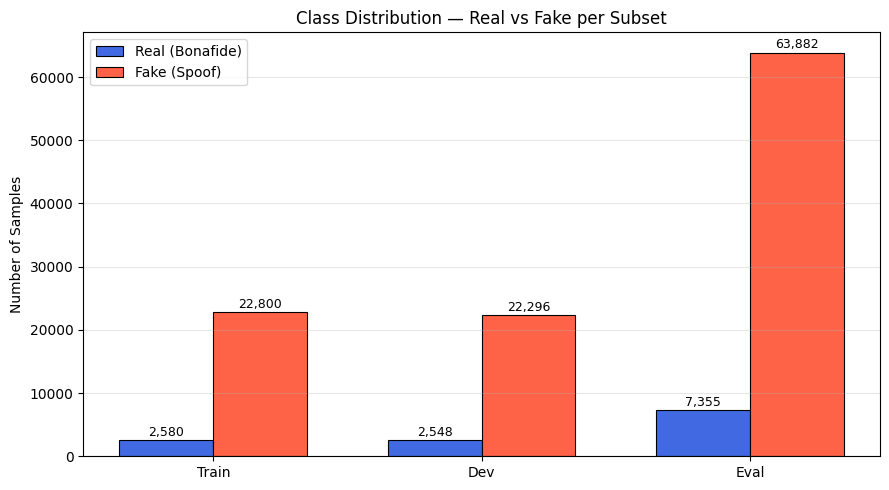

✅ Saved → eda_class_distribution.png


In [3]:
subsets = ['train', 'dev', 'eval']
real_counts = []
fake_counts = []

for subset in subsets:
    proto = config.PROTOCOL_FILES[subset]
    with open(proto, 'r') as f:
        lines = f.readlines()
    real = sum(1 for l in lines if l.strip().split()[4] == 'bonafide')
    fake = sum(1 for l in lines if l.strip().split()[4] == 'spoof')
    real_counts.append(real)
    fake_counts.append(fake)
    print(f"{subset:<6} → Real: {real:>6,} | Fake: {fake:>6,} | Total: {real+fake:>6,} | Fake%: {100*fake/(real+fake):.1f}%")

# Plot
x      = np.arange(len(subsets))
width  = 0.35
fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, real_counts, width, label='Real (Bonafide)', color='royalblue', edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, fake_counts, width, label='Fake (Spoof)',    color='tomato',    edgecolor='black', linewidth=0.8)

ax.set_xticks(x)
ax.set_xticklabels(['Train', 'Dev', 'Eval'])
ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution — Real vs Fake per Subset')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/eda_class_distribution.png", dpi=150)
plt.show()
print(f"✅ Saved → eda_class_distribution.png")

## 2.2 — Audio Duration Distribution

How long are the audio files? Are they consistent or variable length?

[INFO] train → 200 samples | Real: 100 | Fake: 100


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(


Real — Min: 1.45s | Max: 6.19s | Mean: 3.27s
Fake — Min: 1.05s | Max: 9.71s | Mean: 3.19s


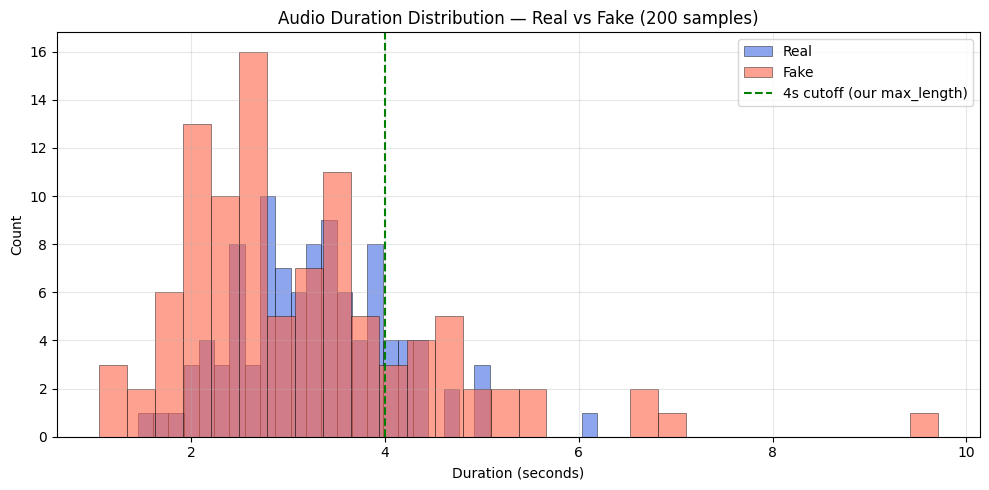

✅ Saved → eda_duration_distribution.png


In [5]:
# Sample 200 files from train (100 real + 100 fake) for speed
train_files, train_labels = load_asvspoof2019(
    config.DATASET_ROOT, config.AUDIO_DIRS, config.PROTOCOL_FILES,
    subset="train", max_samples=200, balanced=True
)

durations_real = []
durations_fake = []

for filepath, label in zip(train_files, train_labels):
    waveform, sr = torchaudio.load(filepath, backend="soundfile")
    duration = waveform.shape[1] / sr
    if label == 0:
        durations_real.append(duration)
    else:
        durations_fake.append(duration)

print(f"Real — Min: {min(durations_real):.2f}s | Max: {max(durations_real):.2f}s | Mean: {np.mean(durations_real):.2f}s")
print(f"Fake — Min: {min(durations_fake):.2f}s | Max: {max(durations_fake):.2f}s | Mean: {np.mean(durations_fake):.2f}s")

# Plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(durations_real, bins=30, alpha=0.6, color='royalblue', label='Real', edgecolor='black', linewidth=0.5)
ax.hist(durations_fake, bins=30, alpha=0.6, color='tomato',    label='Fake', edgecolor='black', linewidth=0.5)
ax.axvline(x=4.0, color='green', linestyle='--', linewidth=1.5, label='4s cutoff (our max_length)')
ax.set_xlabel('Duration (seconds)')
ax.set_ylabel('Count')
ax.set_title('Audio Duration Distribution — Real vs Fake (200 samples)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/eda_duration_distribution.png", dpi=150)
plt.show()
print(f"✅ Saved → eda_duration_distribution.png")

## 2.3 — Waveform Comparison: Real vs Fake

Visualize raw audio waveforms side by side — do real and fake audio look different in the time domain?

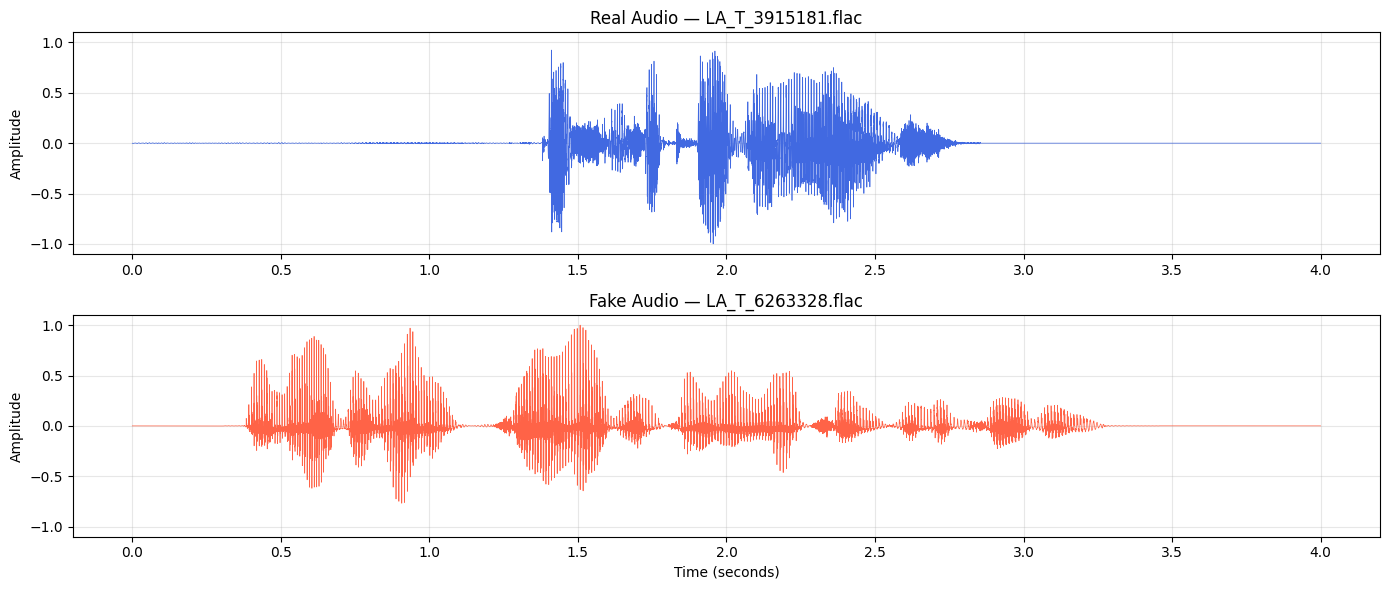

✅ Saved → eda_waveforms.png


In [6]:
# Pick 1 real and 1 fake file
real_file = train_files[train_labels.index(0)]
fake_file = train_files[train_labels.index(1)]

def load_waveform(filepath, target_sr=16000, max_length=64000):
    waveform, sr = torchaudio.load(filepath, backend="soundfile")
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != target_sr:
        waveform = F_audio.resample(waveform, sr, target_sr)
    if waveform.shape[1] > max_length:
        waveform = waveform[:, :max_length]
    else:
        waveform = torch.nn.functional.pad(waveform, (0, max_length - waveform.shape[1]))
    waveform = waveform / (waveform.abs().max() + 1e-8)
    return waveform.squeeze(0).numpy()

real_wave = load_waveform(real_file)
fake_wave = load_waveform(fake_file)
time_axis = np.linspace(0, 4, len(real_wave))

fig, axes = plt.subplots(2, 1, figsize=(14, 6))

axes[0].plot(time_axis, real_wave, color='royalblue', linewidth=0.5)
axes[0].set_title(f'Real Audio — {os.path.basename(real_file)}')
axes[0].set_ylabel('Amplitude')
axes[0].set_ylim(-1.1, 1.1)
axes[0].grid(True, alpha=0.3)

axes[1].plot(time_axis, fake_wave, color='tomato', linewidth=0.5)
axes[1].set_title(f'Fake Audio — {os.path.basename(fake_file)}')
axes[1].set_ylabel('Amplitude')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylim(-1.1, 1.1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/eda_waveforms.png", dpi=150)
plt.show()
print(f"✅ Saved → eda_waveforms.png")

## 2.4 — Mel Spectrogram Comparison: Real vs Fake

Mel spectrograms are what our student CNN actually sees during training. Do real and fake look different in the frequency domain?

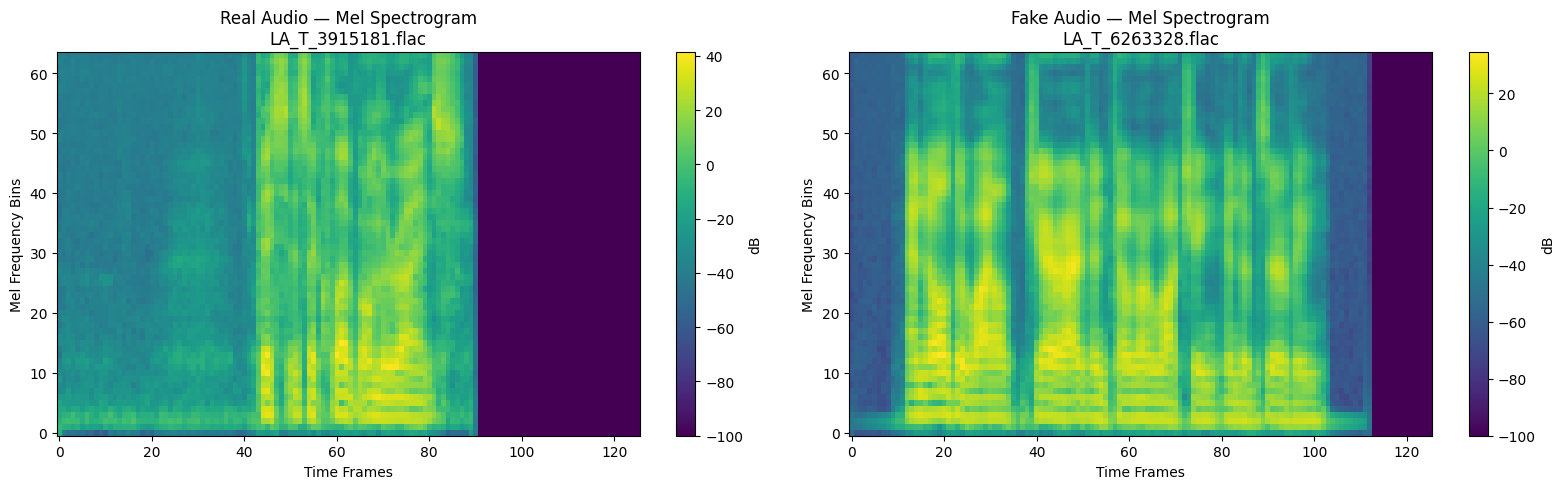

✅ Saved → eda_mel_spectrograms.png


In [7]:
def compute_mel(filepath, target_sr=16000, max_length=64000):
    waveform, sr = torchaudio.load(filepath, backend="soundfile")
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)
    if sr != target_sr:
        waveform = F_audio.resample(waveform, sr, target_sr)
    if waveform.shape[1] > max_length:
        waveform = waveform[:, :max_length]
    else:
        waveform = torch.nn.functional.pad(waveform, (0, max_length - waveform.shape[1]))
    waveform = waveform / (waveform.abs().max() + 1e-8)

    mel_transform = torchaudio.transforms.MelSpectrogram(
        sample_rate=target_sr, n_mels=64, n_fft=1024, hop_length=512
    )
    db_transform = torchaudio.transforms.AmplitudeToDB()
    mel = db_transform(mel_transform(waveform))
    return mel.squeeze(0).numpy()

real_mel = compute_mel(real_file)
fake_mel = compute_mel(fake_file)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

im1 = axes[0].imshow(real_mel, aspect='auto', origin='lower', cmap='viridis')
axes[0].set_title(f'Real Audio — Mel Spectrogram\n{os.path.basename(real_file)}')
axes[0].set_xlabel('Time Frames')
axes[0].set_ylabel('Mel Frequency Bins')
plt.colorbar(im1, ax=axes[0], label='dB')

im2 = axes[1].imshow(fake_mel, aspect='auto', origin='lower', cmap='viridis')
axes[1].set_title(f'Fake Audio — Mel Spectrogram\n{os.path.basename(fake_file)}')
axes[1].set_xlabel('Time Frames')
axes[1].set_ylabel('Mel Frequency Bins')
plt.colorbar(im2, ax=axes[1], label='dB')

plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/eda_mel_spectrograms.png", dpi=150)
plt.show()
print(f"✅ Saved → eda_mel_spectrograms.png")

## 2.5 — Attack Type Breakdown (Train Set)

ASVspoof 2019 LA train set contains 6 attack types (A01–A06), each using a different TTS/voice conversion system. How many samples does each attack contribute?

Attack type breakdown (train set):
  A01 : 3,800 samples
  A02 : 3,800 samples
  A03 : 3,800 samples
  A04 : 3,800 samples
  A05 : 3,800 samples
  A06 : 3,800 samples


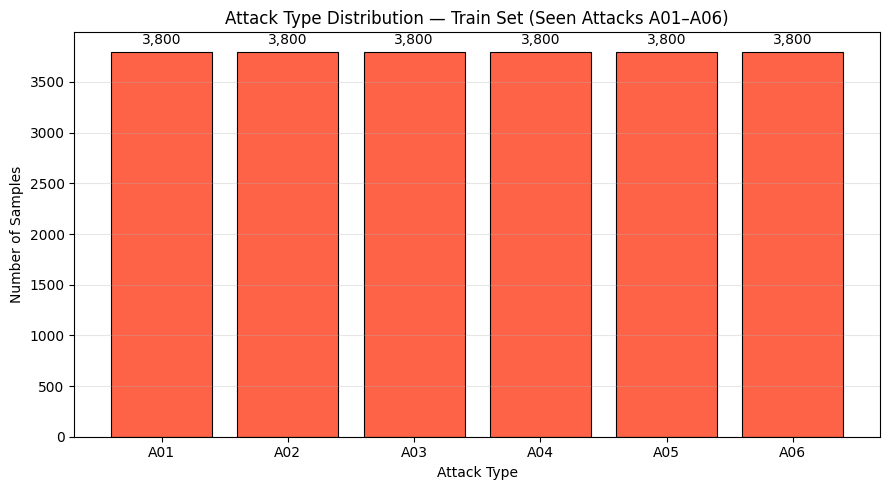

✅ Saved → eda_attack_breakdown.png


In [9]:
proto = config.PROTOCOL_FILES['train']
with open(proto, 'r') as f:
    lines = f.readlines()

attack_counts = {}
for line in lines:
    parts     = line.strip().split()
    label_str = parts[4]
    attack    = parts[3]

    if label_str == 'spoof':
        attack_counts[attack] = attack_counts.get(attack, 0) + 1

attacks = sorted(attack_counts.keys())
counts  = [attack_counts[a] for a in attacks]

print("Attack type breakdown (train set):")
for a, c in zip(attacks, counts):
    print(f"  {a} : {c:,} samples")

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(attacks, counts, color='tomato', edgecolor='black', linewidth=0.8)
ax.set_xlabel('Attack Type')
ax.set_ylabel('Number of Samples')
ax.set_title('Attack Type Distribution — Train Set (Seen Attacks A01–A06)')
ax.grid(True, alpha=0.3, axis='y')

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{count:,}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/eda_attack_breakdown.png", dpi=150)
plt.show()
print(f"✅ Saved → eda_attack_breakdown.png")

## 2.6 — Frequency Content Comparison: Real vs Fake

Average mel energy across all frequency bins — which frequency bands differ most between real and fake audio?

Computing average mel energy for real files...


/usr/local/lib/python3.12/dist-packages/torchaudio/__init__.py:86: UserWarning: The 'backend' parameter is not used by TorchCodec AudioDecoder.
  return load_with_torchcodec(


Computing average mel energy for fake files...


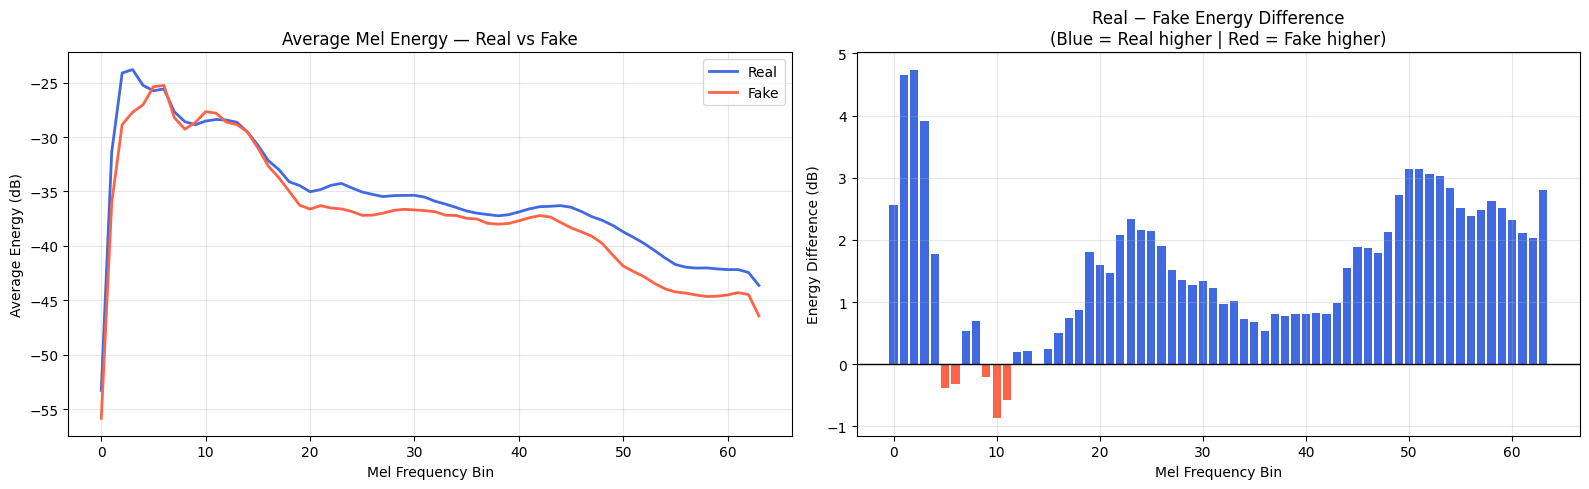

✅ Saved → eda_frequency_content.png


In [10]:
# Compute average mel energy across 50 real and 50 fake files
real_files_sample = [f for f, l in zip(train_files, train_labels) if l == 0][:50]
fake_files_sample = [f for f, l in zip(train_files, train_labels) if l == 1][:50]

def avg_mel_energy(file_list):
    energies = []
    for filepath in file_list:
        mel = compute_mel(filepath)
        energies.append(mel.mean(axis=1))  # mean across time → [64]
    return np.mean(energies, axis=0)       # mean across files → [64]

print("Computing average mel energy for real files...")
real_energy = avg_mel_energy(real_files_sample)
print("Computing average mel energy for fake files...")
fake_energy = avg_mel_energy(fake_files_sample)

mel_bins = np.arange(64)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1 — Overlaid energy curves
axes[0].plot(mel_bins, real_energy, color='royalblue', linewidth=2, label='Real')
axes[0].plot(mel_bins, fake_energy, color='tomato',    linewidth=2, label='Fake')
axes[0].set_xlabel('Mel Frequency Bin')
axes[0].set_ylabel('Average Energy (dB)')
axes[0].set_title('Average Mel Energy — Real vs Fake')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 — Difference (Real - Fake)
diff = real_energy - fake_energy
colors = ['royalblue' if d >= 0 else 'tomato' for d in diff]
axes[1].bar(mel_bins, diff, color=colors, edgecolor='none')
axes[1].axhline(y=0, color='black', linewidth=1)
axes[1].set_xlabel('Mel Frequency Bin')
axes[1].set_ylabel('Energy Difference (dB)')
axes[1].set_title('Real − Fake Energy Difference\n(Blue = Real higher | Red = Fake higher)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.SAVE_DIR}/eda_frequency_content.png", dpi=150)
plt.show()
print(f"✅ Saved → eda_frequency_content.png")

## 2.7 — Summary

Key findings from the exploratory analysis before training.

In [11]:
print("=" * 55)
print("  EDA SUMMARY — ASVspoof 2019 LA")
print("=" * 55)
print(f"""
  Dataset:
  ├── Train : 25,380 samples (2,580 real | 22,800 fake)
  ├── Dev   : 24,844 samples (2,548 real | 22,296 fake)
  └── Eval  : 71,237 samples (7,355 real | 63,882 fake)

  Class Imbalance:
  └── ~90% fake across all subsets
      → Balanced sampling used during training

  Audio Duration:
  ├── Range : ~1s – 9.7s
  ├── Mean  : ~3.2s
  └── Files longer than 4s are truncated
      Files shorter than 4s are zero-padded

  Attack Types (Train):
  ├── 6 seen attacks (A01–A06)
  ├── 3,800 samples each — perfectly balanced
  └── 13 unseen attacks (A07–A19) in eval set

  Waveform Differences:
  └── Real audio has natural silence + organic amplitude
      Fake audio has uniform burst patterns (TTS artifacts)

  Frequency Differences:
  └── Real audio has higher energy across most mel bins
      Biggest gap at low frequencies (bins 0–5)
      → CNN learns these frequency signatures
""")
print("=" * 55)
print("  Next → 3_hyperparameter_sweep.ipynb")
print("=" * 55)

  EDA SUMMARY — ASVspoof 2019 LA

  Dataset:
  ├── Train : 25,380 samples (2,580 real | 22,800 fake)
  ├── Dev   : 24,844 samples (2,548 real | 22,296 fake)
  └── Eval  : 71,237 samples (7,355 real | 63,882 fake)

  Class Imbalance:
  └── ~90% fake across all subsets
      → Balanced sampling used during training

  Audio Duration:
  ├── Range : ~1s – 9.7s
  ├── Mean  : ~3.2s
  └── Files longer than 4s are truncated
      Files shorter than 4s are zero-padded

  Attack Types (Train):
  ├── 6 seen attacks (A01–A06)
  ├── 3,800 samples each — perfectly balanced
  └── 13 unseen attacks (A07–A19) in eval set

  Waveform Differences:
  └── Real audio has natural silence + organic amplitude
      Fake audio has uniform burst patterns (TTS artifacts)

  Frequency Differences:
  └── Real audio has higher energy across most mel bins
      Biggest gap at low frequencies (bins 0–5)
      → CNN learns these frequency signatures

  Next → 3_hyperparameter_sweep.ipynb
